# Deep Learning Models (CNN, BiLSTM)

Melatih arsitektur Deep Learning menggunakan TensorFlow/Keras.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, precision_recall_fscore_support
)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense,
    Dropout, Bidirectional, LSTM, MaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

# Styling global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load Data

In [2]:
train_df = pd.read_csv('../data/train.csv').fillna('')
val_df = pd.read_csv('../data/val.csv').fillna('')
test_df = pd.read_csv('../data/test.csv').fillna('')

X_train, y_train = train_df['text'], train_df['label']
X_val, y_val = val_df['text'], val_df['label']
X_test, y_test = test_df['text'], test_df['label']

le = joblib.load('../models/label_encoder.pkl')
num_classes = len(le.classes_)

## 2. Tokenisasi & Padding

In [3]:
max_words = 30000
max_len = 256  # Berdasarkan EDA

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

# Simpan tokenizer
import pickle
with open('../models/dl_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

## 3. Definisi Model

In [4]:
def create_cnn():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

def create_bilstm():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Bidirectional(LSTM(128, return_sequences=False)),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

def create_cnn_bilstm():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation="relu"),
        MaxPooling1D(pool_size=2),
        Bidirectional(LSTM(128)),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

## 4. Training Model

In [5]:
model_configs = {
    'CNN': create_cnn(),
    'BiLSTM': create_bilstm(),
    'CNN-BiLSTM': create_cnn_bilstm()
}
results = []
all_histories = {}   # simpan history untuk visualisasi
all_predictions = {} # simpan prediksi untuk confusion matrix
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for name, model in model_configs.items():
    print(f"\nTraining {name}...")
    history = model.fit(
        X_train_pad, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val_pad, y_val),
        callbacks=[early_stop],
        verbose=1
    )
    all_histories[name] = history

    print(f"Evaluating {name}...")
    y_pred_probs = model.predict(X_test_pad)
    y_pred = np.argmax(y_pred_probs, axis=1)
    all_predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    model.save(f'../models/{name.lower()}_model.h5')


Training CNN...
Epoch 1/10


c:\Users\Monk\miniconda3\envs\myenvironment\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


647/647 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6946 - loss: 0.9646 - val_accuracy: 0.8462 - val_loss: 0.4694
Epoch 2/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8906 - loss: 0.3690 - val_accuracy: 0.8626 - val_loss: 0.4066
Epoch 3/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9411 - loss: 0.1911 - val_accuracy: 0.8732 - val_loss: 0.4216
Epoch 4/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9737 - loss: 0.0901 - val_accuracy: 0.8786 - val_loss: 0.4708
Epoch 5/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9876 - loss: 0.0437 - val_accuracy: 0.8757 - val_loss: 0.5137
Evaluating CNN...
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


                         precision    recall  f1-score   support

                   APBN       0.62      0.15      0.24        55
             Agribisnis       0.92      0.35      0.51        66
                Ekonomi       0.80      0.84      0.82       775
         Ekonomi Global       0.94      0.92      0.93       331
       Energi & Tambang       0.92      0.95      0.93       557
          Infrastruktur       0.95      0.80      0.87       222
           Jasa & Niaga       0.84      0.86      0.85       693
             Manufaktur       0.81      0.78      0.79       312
                  Pajak       0.80      0.78      0.79       107
               Properti       0.87      0.93      0.90       306
Transportasi & Logistik       0.94      0.98      0.96      1010

               accuracy                           0.88      4434
              macro avg       0.86      0.76      0.78      4434
           weighted avg       0.88      0.88      0.87      4434


Training BiLSTM...
Ep

                         precision    recall  f1-score   support

                   APBN       0.00      0.00      0.00        55
             Agribisnis       0.00      0.00      0.00        66
                Ekonomi       0.78      0.80      0.79       775
         Ekonomi Global       0.72      0.92      0.81       331
       Energi & Tambang       0.89      0.93      0.91       557
          Infrastruktur       0.84      0.85      0.84       222
           Jasa & Niaga       0.79      0.83      0.81       693
             Manufaktur       0.75      0.61      0.67       312
                  Pajak       0.62      0.56      0.59       107
               Properti       0.89      0.88      0.88       306
Transportasi & Logistik       0.93      0.95      0.94      1010

               accuracy                           0.83      4434
              macro avg       0.66      0.67      0.66      4434
           weighted avg       0.81      0.83      0.82      4434


Training CNN-BiLSTM..

                         precision    recall  f1-score   support

                   APBN       0.00      0.00      0.00        55
             Agribisnis       0.00      0.00      0.00        66
                Ekonomi       0.76      0.83      0.79       775
         Ekonomi Global       0.71      0.80      0.75       331
       Energi & Tambang       0.93      0.94      0.93       557
          Infrastruktur       0.70      0.93      0.80       222
           Jasa & Niaga       0.86      0.76      0.81       693
             Manufaktur       0.60      0.78      0.68       312
                  Pajak       0.69      0.51      0.59       107
               Properti       0.90      0.78      0.83       306
Transportasi & Logistik       0.96      0.95      0.96      1010

               accuracy                           0.82      4434
              macro avg       0.65      0.66      0.65      4434
           weighted avg       0.81      0.82      0.82      4434



## 5. Visualisasi — Training History (Accuracy & Loss)

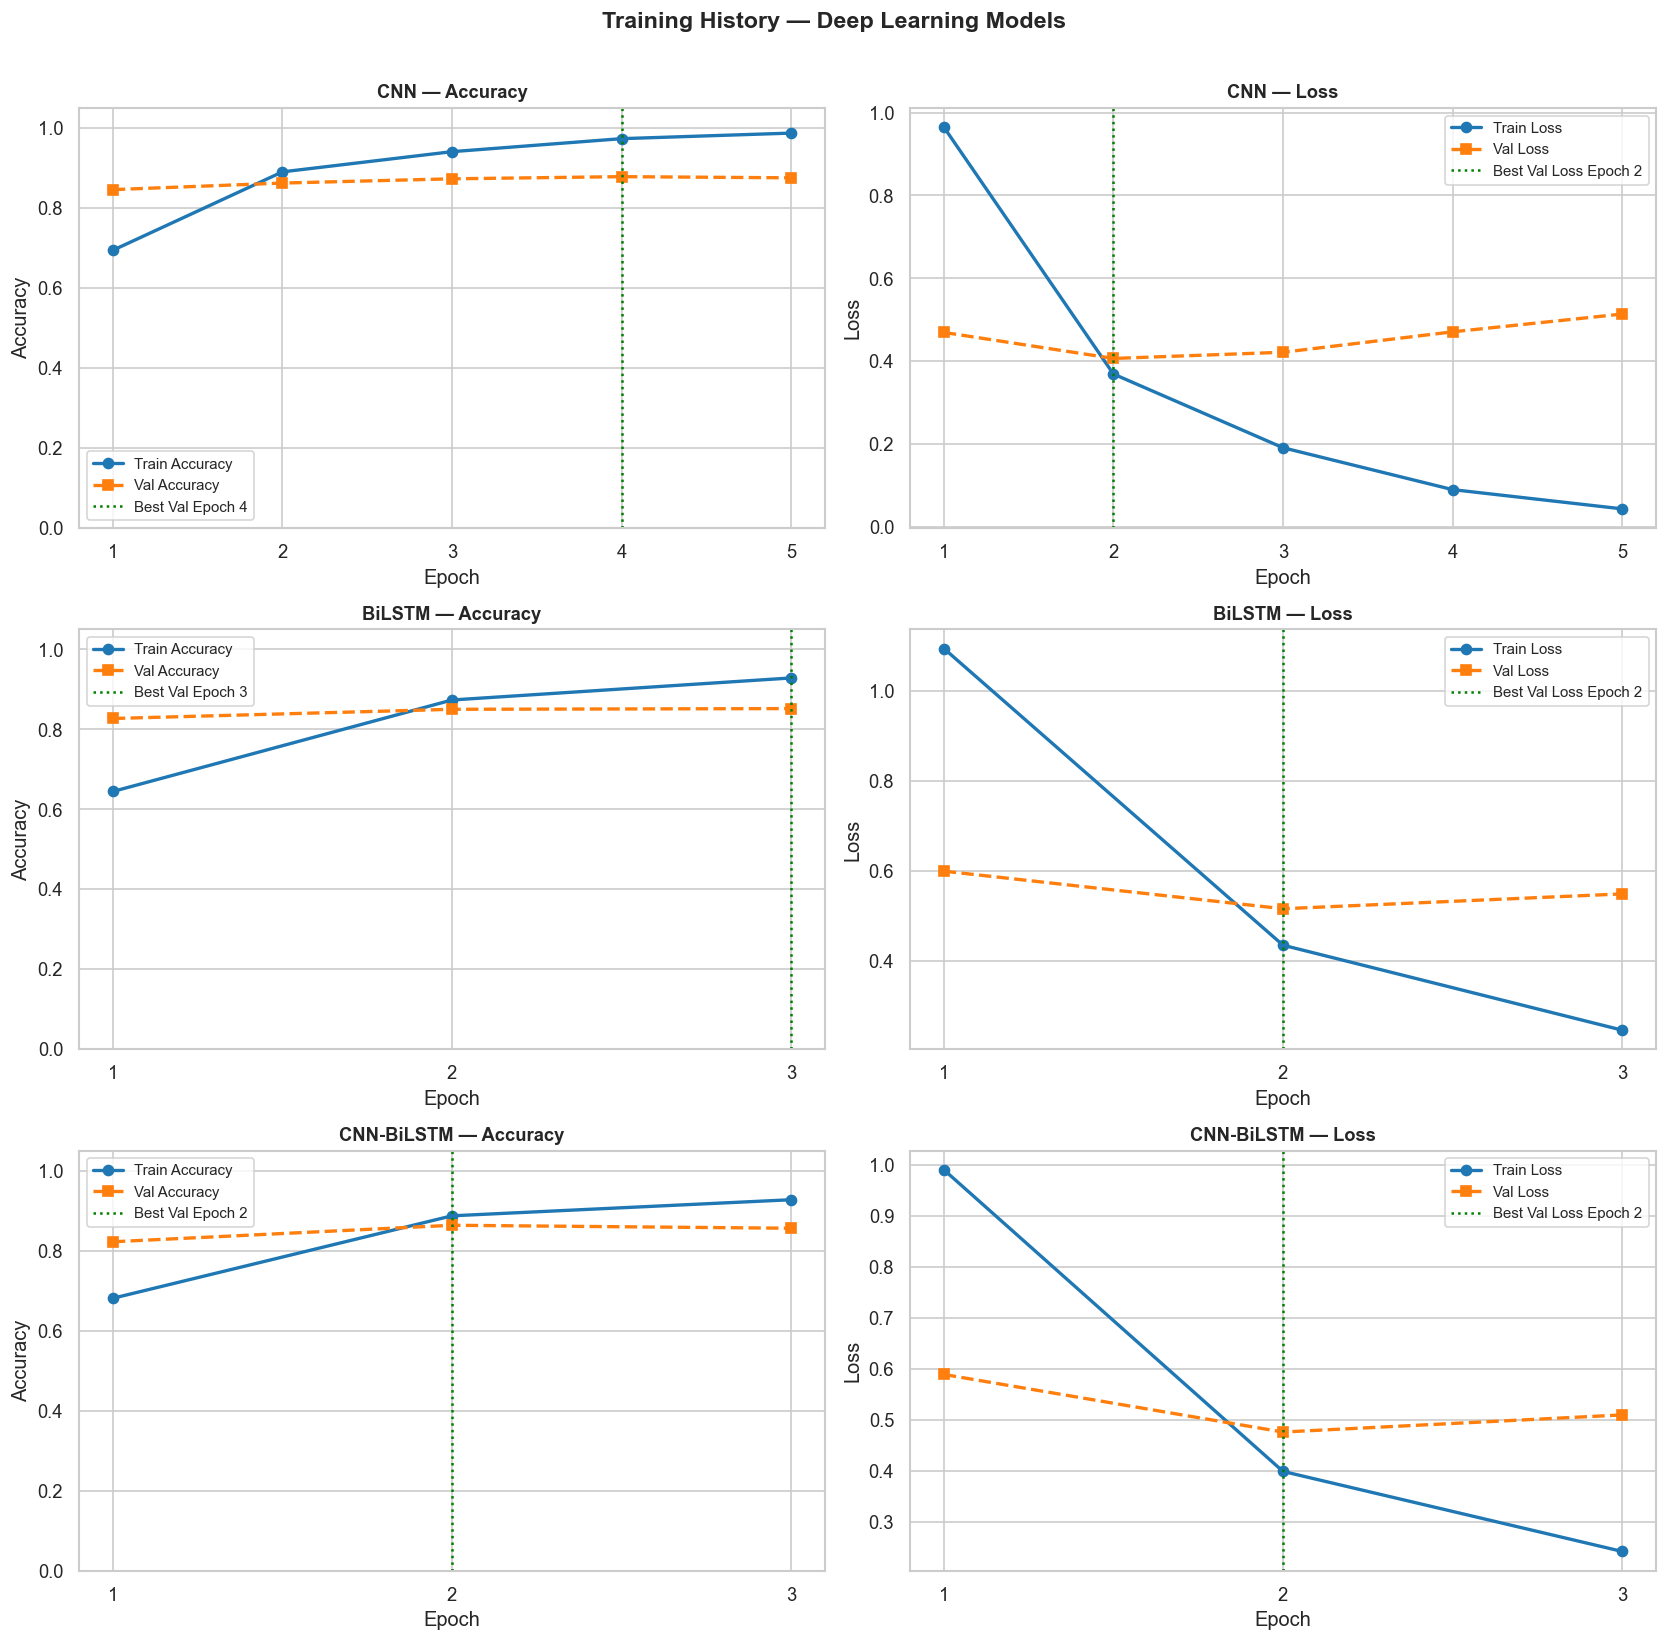

✓ Gambar disimpan: ../outputs/figures/dl_training_history.png


In [6]:
def plot_training_history(histories):
    """Plot kurva training & validation accuracy + loss untuk setiap model."""
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n))
    if n == 1:
        axes = [axes]

    color_train = '#1f77b4'
    color_val   = '#ff7f0e'

    for row, (name, history) in enumerate(histories.items()):
        hist = history.history
        epochs = range(1, len(hist['accuracy']) + 1)

        # --- Accuracy ---
        ax_acc = axes[row][0]
        ax_acc.plot(epochs, hist['accuracy'],    'o-', color=color_train, label='Train Accuracy', linewidth=2)
        ax_acc.plot(epochs, hist['val_accuracy'], 's--', color=color_val,   label='Val Accuracy',   linewidth=2)
        ax_acc.set_title(f'{name} — Accuracy', fontsize=11, fontweight='bold')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.set_ylim(0, 1.05)
        ax_acc.legend(fontsize=9)
        ax_acc.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        # Tandai epoch terbaik
        best_epoch = np.argmax(hist['val_accuracy']) + 1
        ax_acc.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5,
                       label=f'Best Val Epoch {best_epoch}')
        ax_acc.legend(fontsize=9)

        # --- Loss ---
        ax_loss = axes[row][1]
        ax_loss.plot(epochs, hist['loss'],     'o-', color=color_train, label='Train Loss', linewidth=2)
        ax_loss.plot(epochs, hist['val_loss'], 's--', color=color_val,   label='Val Loss',   linewidth=2)
        ax_loss.set_title(f'{name} — Loss', fontsize=11, fontweight='bold')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend(fontsize=9)
        ax_loss.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        best_loss_epoch = np.argmin(hist['val_loss']) + 1
        ax_loss.axvline(best_loss_epoch, color='green', linestyle=':', linewidth=1.5,
                        label=f'Best Val Loss Epoch {best_loss_epoch}')
        ax_loss.legend(fontsize=9)

    plt.suptitle('Training History — Deep Learning Models', fontsize=14,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/dl_training_history.png', bbox_inches='tight')
    plt.show()
    print('✓ Gambar disimpan: ../outputs/figures/dl_training_history.png')

plot_training_history(all_histories)

## 6. Visualisasi — Confusion Matrix

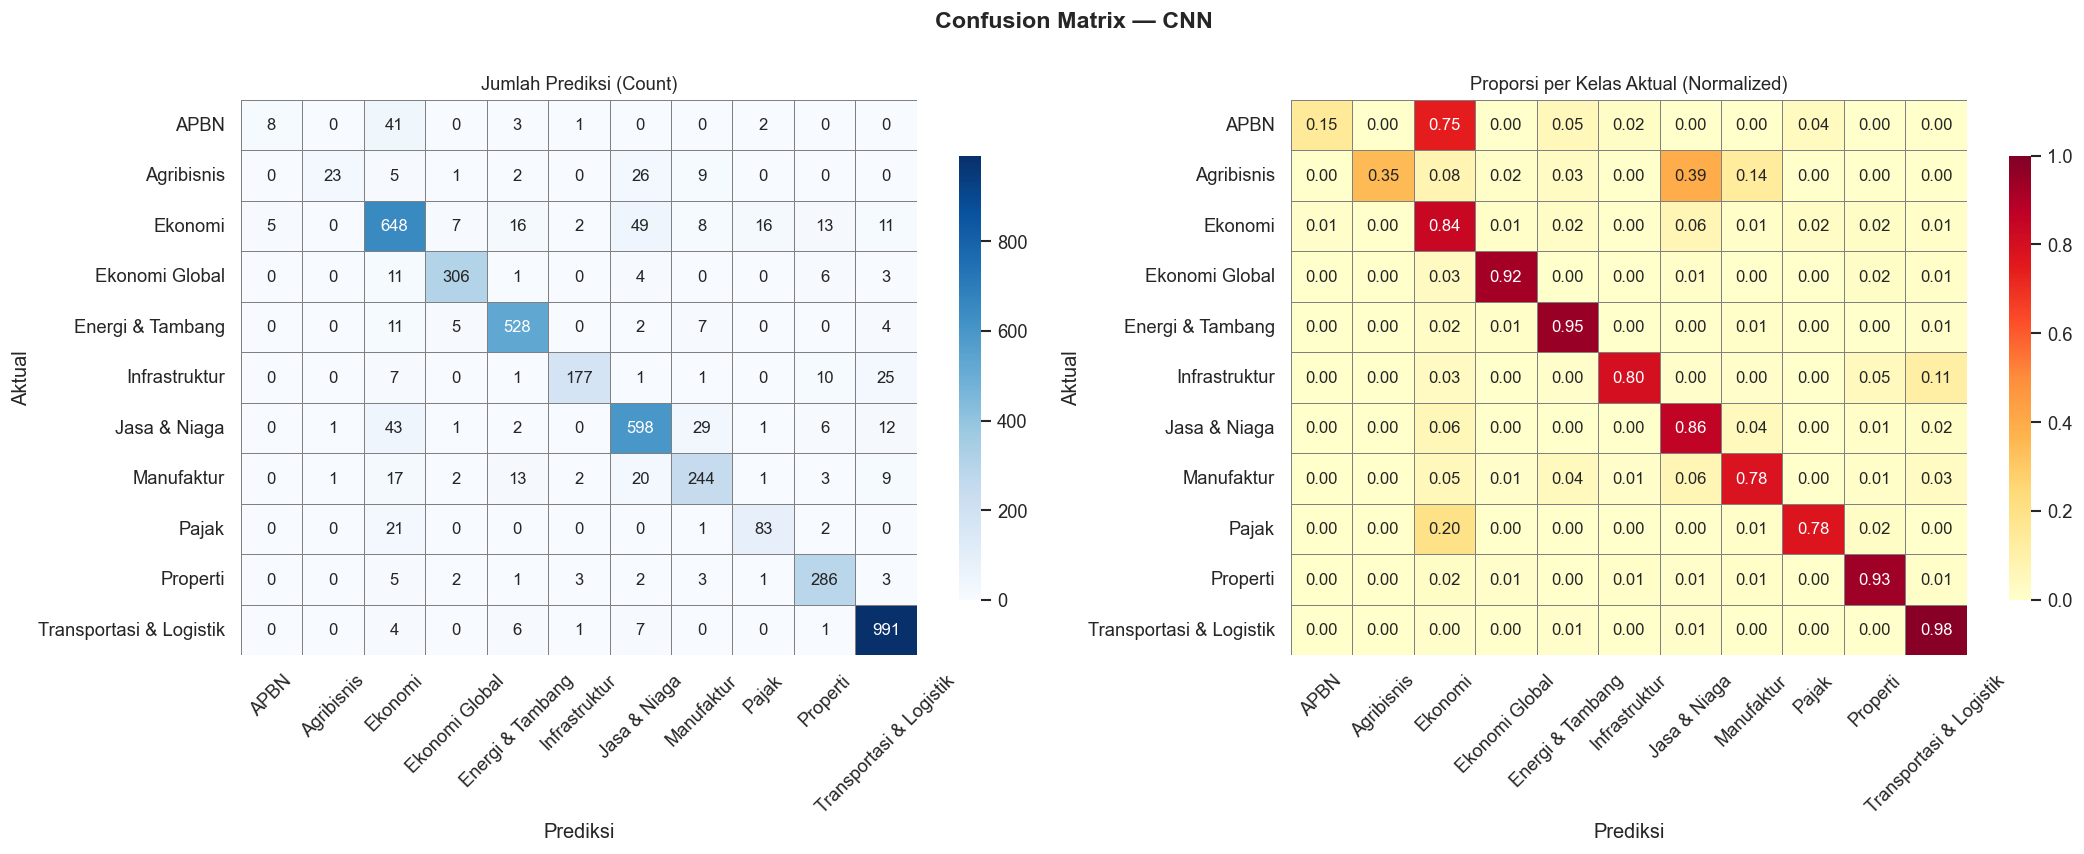

  ✓ Gambar disimpan: ../outputs/figures/cm_dl_cnn.png



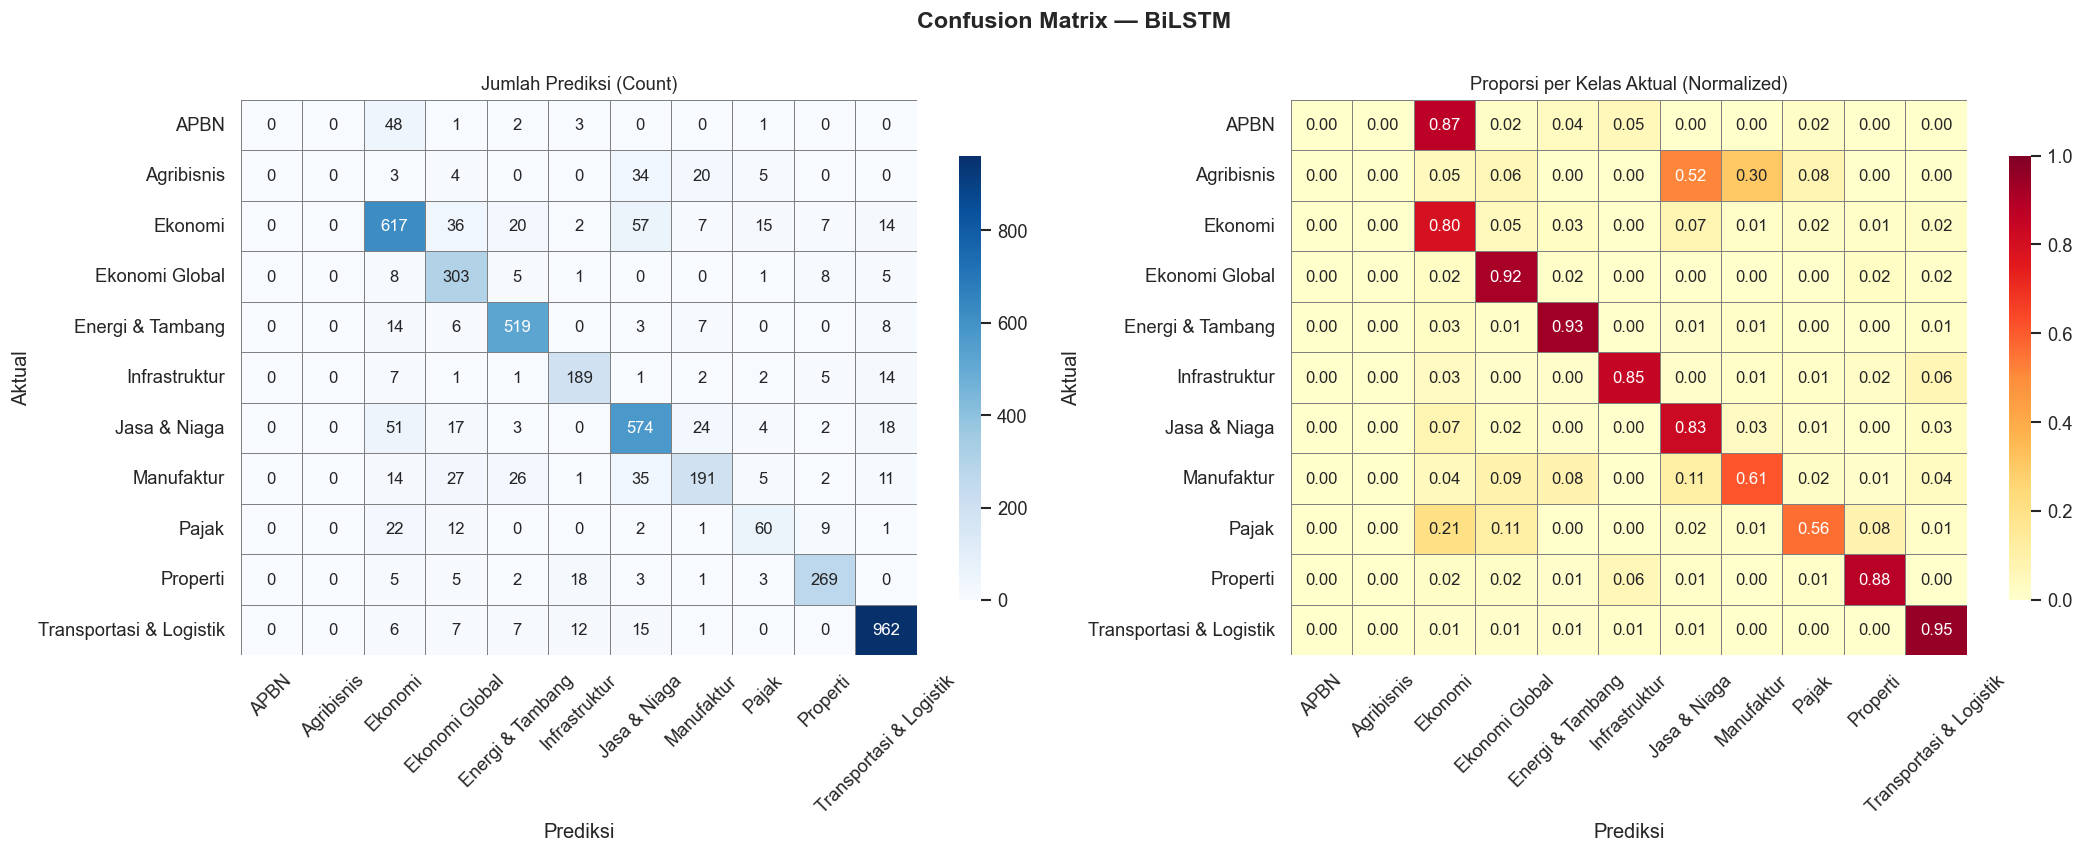

  ✓ Gambar disimpan: ../outputs/figures/cm_dl_bilstm.png



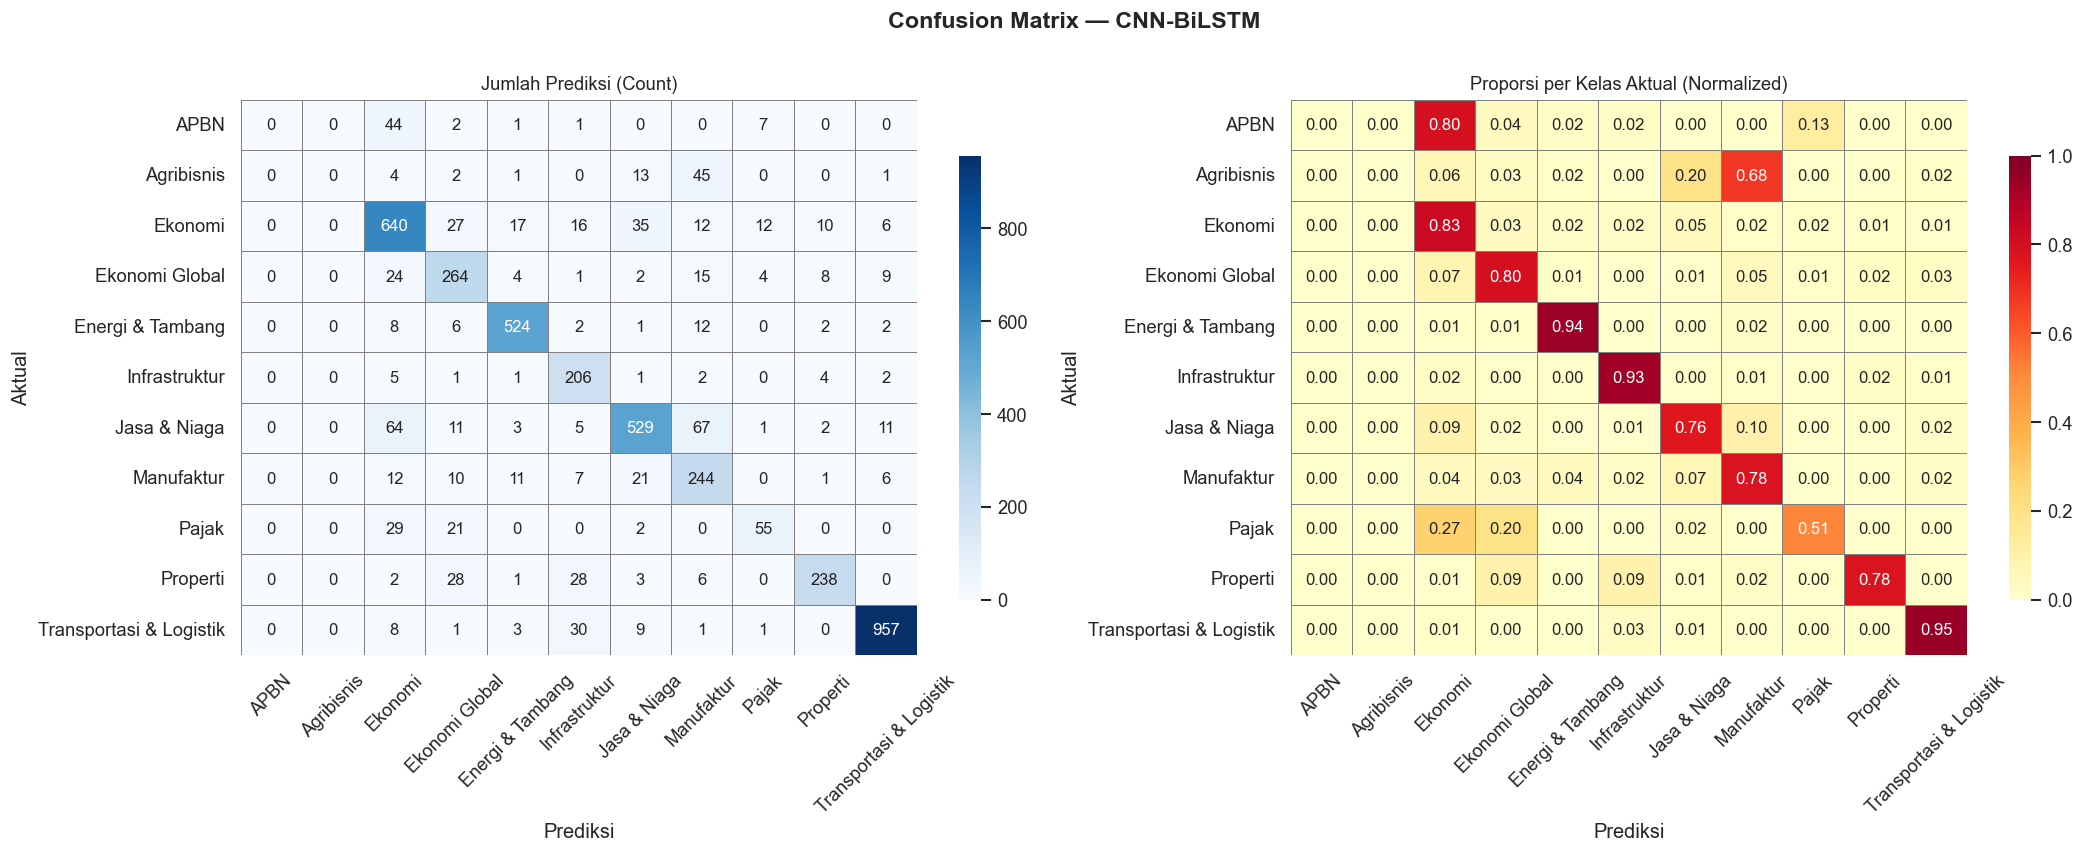

  ✓ Gambar disimpan: ../outputs/figures/cm_dl_cnn_bilstm.png



In [7]:
def plot_confusion_matrix(y_true, y_pred, model_name, target_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold', y=1.01)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=target_names, yticklabels=target_names,
        linewidths=0.5, linecolor='grey',
        ax=axes[0], cbar_kws={'shrink': 0.8}
    )
    axes[0].set_title('Jumlah Prediksi (Count)', fontsize=11)
    axes[0].set_xlabel('Prediksi')
    axes[0].set_ylabel('Aktual')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
        xticklabels=target_names, yticklabels=target_names,
        linewidths=0.5, linecolor='grey', vmin=0, vmax=1,
        ax=axes[1], cbar_kws={'shrink': 0.8}
    )
    axes[1].set_title('Proporsi per Kelas Aktual (Normalized)', fontsize=11)
    axes[1].set_xlabel('Prediksi')
    axes[1].set_ylabel('Aktual')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    os.makedirs('../outputs/figures', exist_ok=True)
    fname = f'../outputs/figures/cm_dl_{model_name.replace("-", "_").lower()}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'  ✓ Gambar disimpan: {fname}\n')

for name, y_pred in all_predictions.items():
    plot_confusion_matrix(y_test, y_pred, name, le.classes_)

## 7. Visualisasi — Metrik per Kelas (F1-Score)

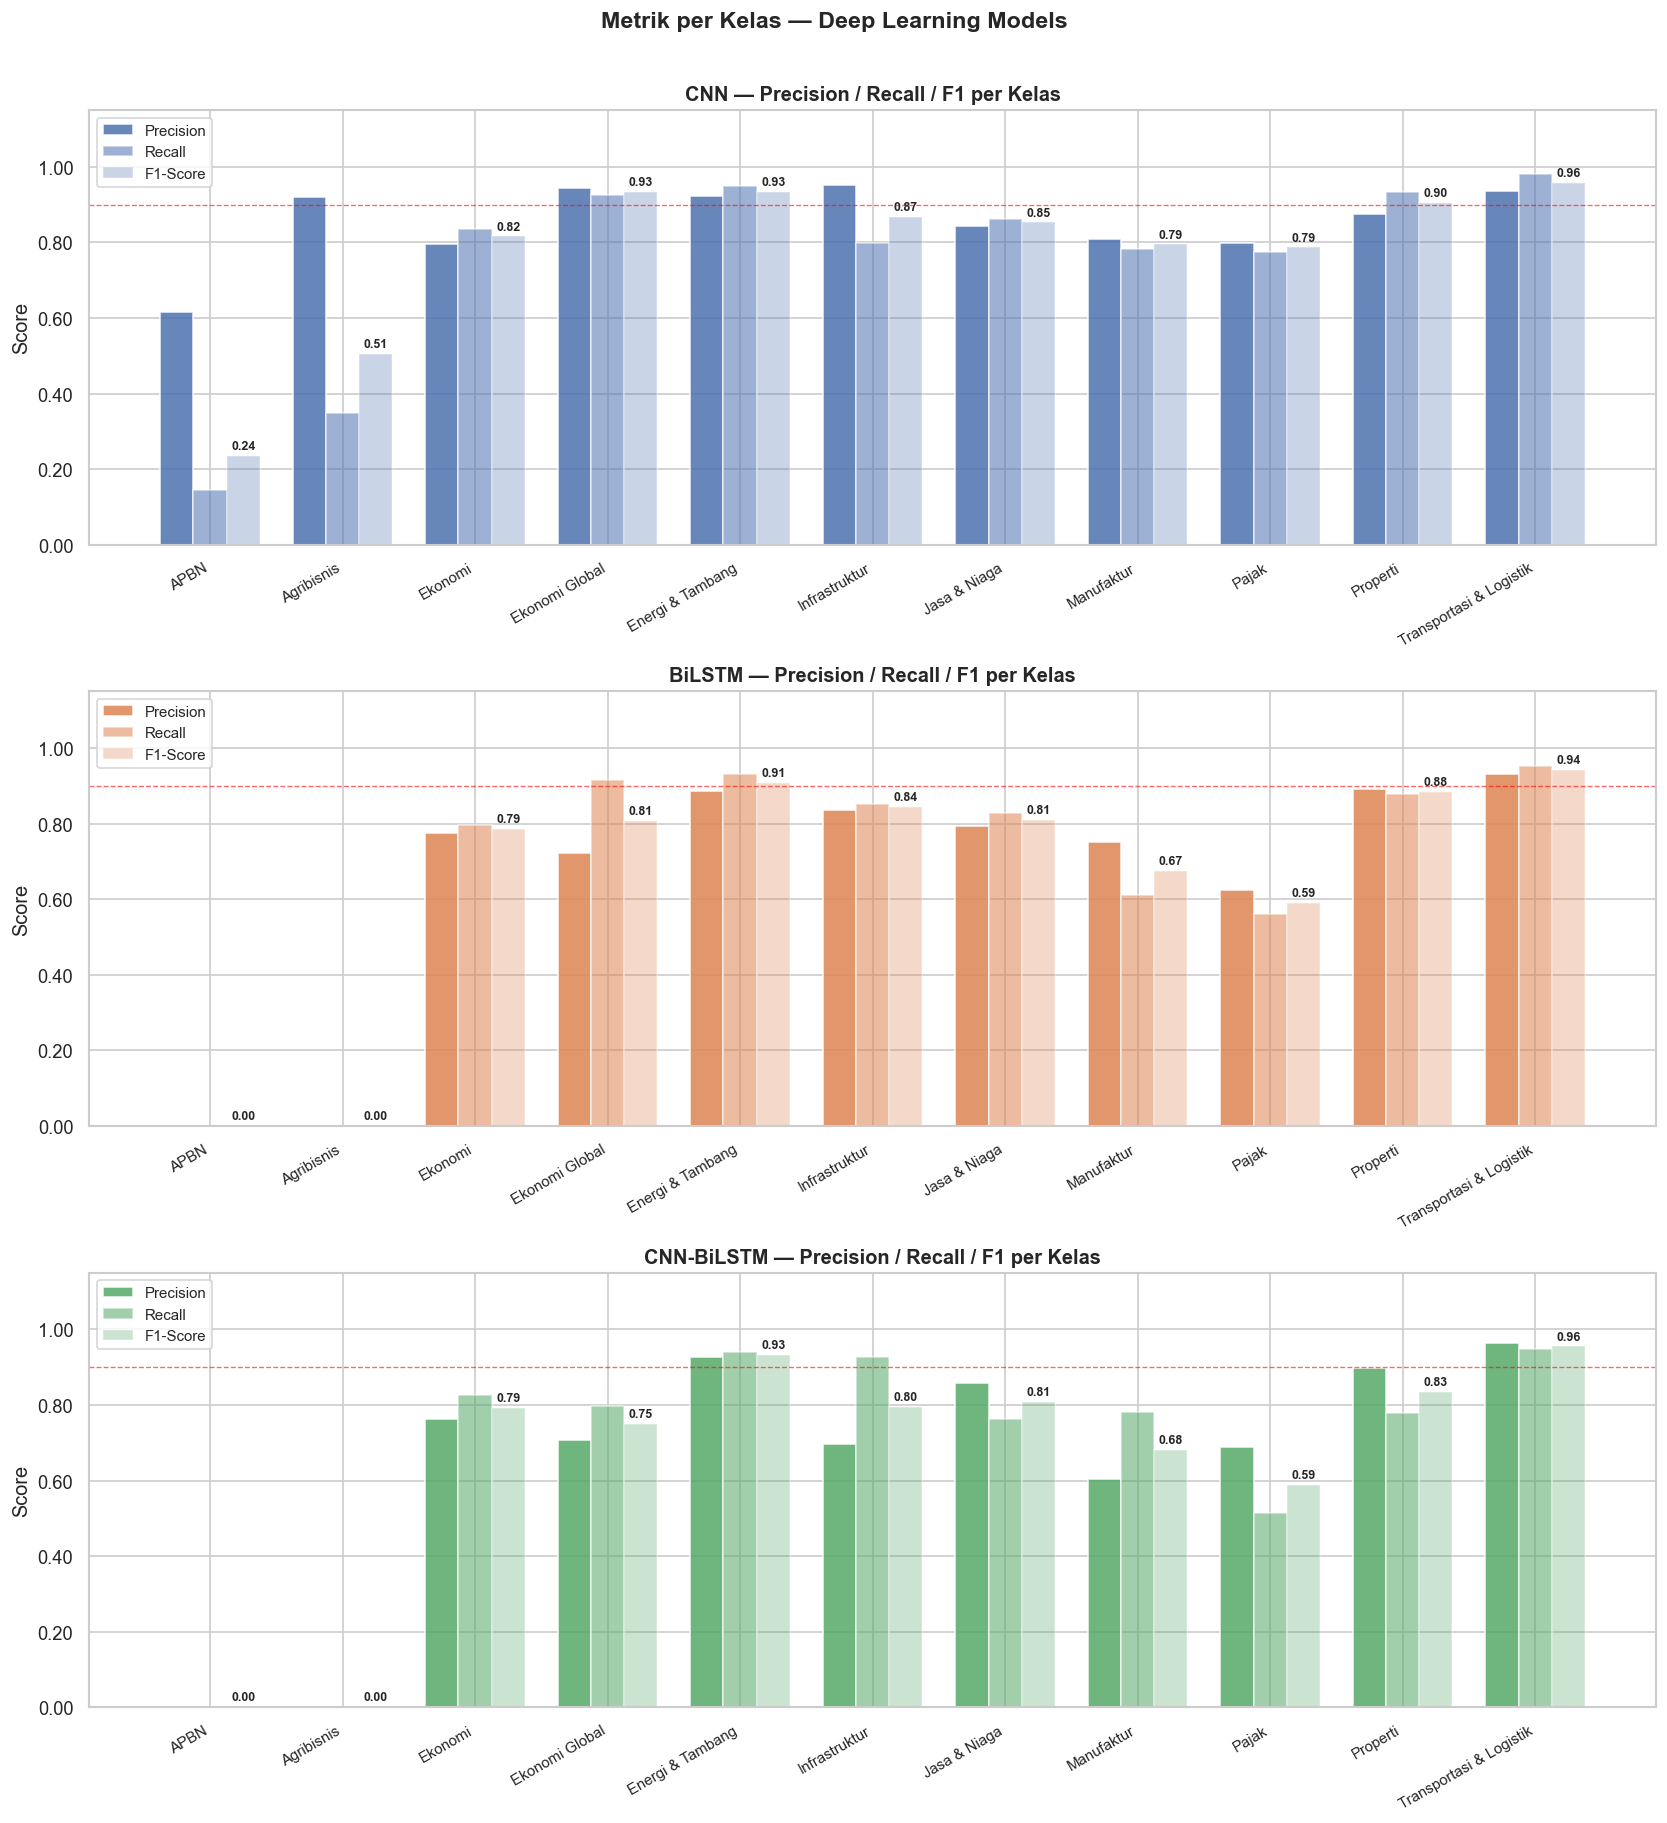

✓ Gambar disimpan: ../outputs/figures/dl_per_class_metrics.png


In [8]:
fig, axes = plt.subplots(len(all_predictions), 1,
                          figsize=(14, 5 * len(all_predictions)),
                          sharex=False)
if len(all_predictions) == 1:
    axes = [axes]

colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, (name, y_pred), color in zip(axes, all_predictions.items(), colors):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=np.arange(len(le.classes_)), zero_division=0
    )

    x = np.arange(len(le.classes_))
    width = 0.25

    bars_p = ax.bar(x - width, prec, width, label='Precision', color=color, alpha=0.85)
    bars_r = ax.bar(x,         rec,  width, label='Recall',    color=color, alpha=0.55)
    bars_f = ax.bar(x + width, f1,   width, label='F1-Score',  color=color, alpha=0.30)

    for bar, val in zip(bars_f, f1):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_title(f'{name} — Precision / Recall / F1 per Kelas', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(le.classes_, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Metrik per Kelas — Deep Learning Models', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/dl_per_class_metrics.png', bbox_inches='tight')
plt.show()
print('✓ Gambar disimpan: ../outputs/figures/dl_per_class_metrics.png')

## 8. Visualisasi — Perbandingan Keseluruhan Model DL

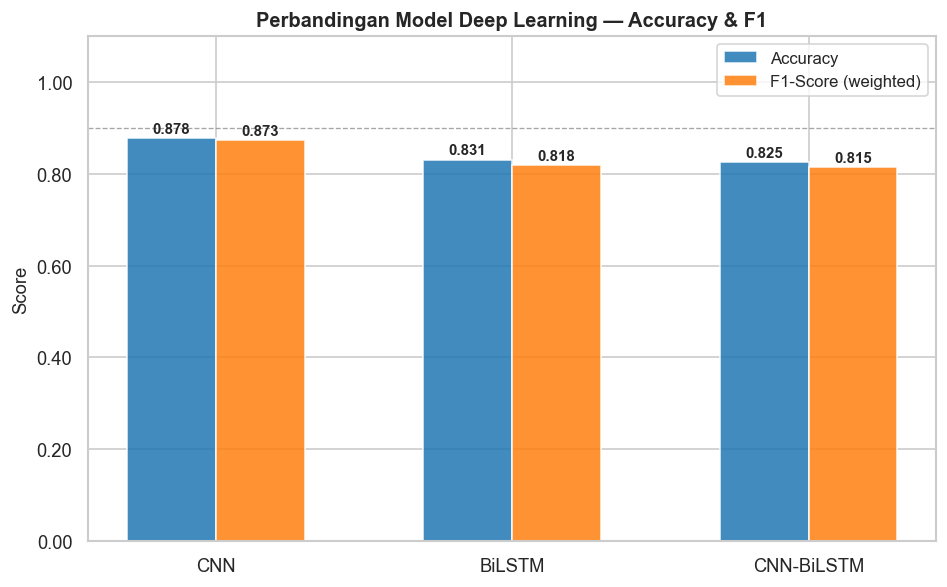

✓ Gambar disimpan: ../outputs/figures/dl_overall_comparison.png


In [9]:
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.3

bars_acc = ax.bar(x - width/2, results_df['Accuracy'], width,
                  label='Accuracy', color='#1f77b4', alpha=0.85)
bars_f1  = ax.bar(x + width/2, results_df['F1-Score'], width,
                  label='F1-Score (weighted)', color='#ff7f0e', alpha=0.85)

for bars in [bars_acc, bars_f1]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Perbandingan Model Deep Learning — Accuracy & F1',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('../outputs/figures/dl_overall_comparison.png', bbox_inches='tight')
plt.show()
print('✓ Gambar disimpan: ../outputs/figures/dl_overall_comparison.png')

## 9. Simpan Hasil

In [10]:
os.makedirs('../outputs', exist_ok=True)
results_df.to_csv('../outputs/dl_results.csv', index=False)
print("Hasil Deep Learning disimpan ke '../outputs/dl_results.csv'")
print(results_df.to_string(index=False))

Hasil Deep Learning disimpan ke '../outputs/dl_results.csv'
     Model  Accuracy  F1-Score
       CNN  0.877763  0.872587
    BiLSTM  0.830853  0.818083
CNN-BiLSTM  0.824763  0.815133
